In [1]:
#=nb

In [2]:
import torch
from torch import nn
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor, Normalize
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os

In [6]:
path = os.listdir('data')
f'idx0 {path[0]},    idx1 {path[1]},    idx2 {path[2]},    idx3 {path[3]}'

'idx0 test_img.npy,    idx1 test_lbl.npy,    idx2 train_img.npy,    idx3 train_lbl.npy'

In [7]:
train_img = np.load(f'data//{path[2]}').reshape(75000, 28,28)
train_lbl = np.load(f'data//{path[3]}')
test_img = np.load(f'data//{path[0]}').reshape(25000 ,28,28)
test_lbl = np.load(f'data//{path[1]}')

In [8]:
train_img.shape, train_lbl.shape, test_img.shape, test_lbl.shape

((75000, 28, 28), (75000,), (25000, 28, 28), (25000,))

In [34]:
train_lbl[0]

np.float64(0.0)

In [35]:
transform = transforms.Compose([
    ToTensor(),
    Normalize((0.5), (0.5))
])

In [36]:
class Doodles(Dataset):
    def __init__(self, target, img, transform = None):
        self.target = target
        self.img = img
        self.transform = transform
    def __len__(self):
        return len(self.target)
    def __getitem__(self,idx):
        img = self.img[idx]
        lbl = torch.tensor(self.target[idx]).int()
        if self.transform:
            img = self.transform(img).float()

        return (img, lbl.item())

In [37]:
train_data = Doodles(train_lbl, train_img, transform)
test_data = Doodles(test_lbl, test_img, transform)

In [38]:
img,lbl = train_data[0]
img.min(), img.max()

(tensor(-1.), tensor(1.))

In [39]:
test_dataloader = DataLoader(test_data, batch_size = 256, shuffle = True)
train_dataloader = DataLoader(train_data, batch_size = 256, shuffle = True)

In [9]:
divice = ("cuda"
   if torch.cuda.is_available()
   else "mps"
   if torch.backends.mps.is_available()
   else "cpu")
divice

'cpu'

In [10]:
class ConvNet(nn.Module):
  def __init__(self):
    super(ConvNet, self).__init__()
    self.flatten = nn.Flatten()
    self.conv = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.Conv2d(32,32, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(64,64, kernel_size = 3 , padding = 1),
        nn.ReLU()
    )
    '''
    zeros = torch.zeros(1,1,28,28)
    output = self.conv(zeros)
    print(self.flatten(output).shape)'''
    self.fc = nn.Sequential(
        nn.Linear(12544, 256),
        nn.ReLU(),
        nn.Linear(256, 500),
        nn.ReLU(),
        nn.Linear(500, 10)
    )
  def forward(self, x):
    X = self.conv(x)
    X = self.flatten(X)
    X = self.fc(X)
    return X
model = ConvNet().to(divice)


In [52]:
x, y = next(iter(train_dataloader))
img =  x[0].reshape(1,1, 28,28)
model(img).shape

torch.Size([1, 10])

In [53]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3, betas=(0.9, 0.999), eps= 1e-08, weight_decay = 0, amsgrad = False)

In [54]:
def train(model,dataloader, optimizer, loss_fn, print_every = 1):
  model.train()
  size = len(dataloader.dataset)
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(divice), y.to(divice)
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % print_every == 0:
      current = (batch + 1) * len(X)
      print(f"loss: {loss.item():.4f},[Current: {current}/{size}]")


In [55]:
def test(model, dataloader, loss_fn, print_every = 1):
  model.eval()
  num_batches = len(dataloader)
  test_loss, correct = 0 , 0
  with torch.no_grad():
    for X,y in dataloader:
      X,y = X.to(divice), y.to(divice)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= len(dataloader.dataset)
  print(f"Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [56]:
epoches = 10
for t in range(epoches):
  print(f"Epoch {t+1}\n-------------------------------")
  train(model, train_dataloader, optimizer, loss_fn, print_every = 1000)
  test(model, test_dataloader, loss_fn, print_every = 10)
print("Done!")

Epoch 1
-------------------------------
loss: 2.3022,[Current: 256/75000]
Accuracy: 89.4%, Avg loss: 0.351752 

Epoch 2
-------------------------------
loss: 0.3171,[Current: 256/75000]
Accuracy: 91.1%, Avg loss: 0.292638 

Epoch 3
-------------------------------
loss: 0.2027,[Current: 256/75000]
Accuracy: 91.1%, Avg loss: 0.287337 

Epoch 4
-------------------------------
loss: 0.1026,[Current: 256/75000]
Accuracy: 91.4%, Avg loss: 0.301402 

Epoch 5
-------------------------------
loss: 0.1507,[Current: 256/75000]
Accuracy: 91.5%, Avg loss: 0.322217 

Epoch 6
-------------------------------
loss: 0.0808,[Current: 256/75000]
Accuracy: 91.7%, Avg loss: 0.370053 

Epoch 7
-------------------------------
loss: 0.0427,[Current: 256/75000]
Accuracy: 91.7%, Avg loss: 0.369589 

Epoch 8
-------------------------------
loss: 0.0459,[Current: 256/75000]
Accuracy: 91.7%, Avg loss: 0.433792 

Epoch 9
-------------------------------
loss: 0.0215,[Current: 256/75000]
Accuracy: 91.1%, Avg loss: 0.4

In [57]:
torch.save(model.state_dict(), "model.pth")
print("model saved")

model saved


In [11]:
model = ConvNet().to(divice)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [54]:
classes = {
    0: "airpalne",
    1 : "alarm",
    2 : "ant",
    3 : "apple",
    4 : "arm",
    5 : "axe",
    6 : "bat",
    7 : "bed",
    8 : "birthday_cake",
    9 : "camera"
}

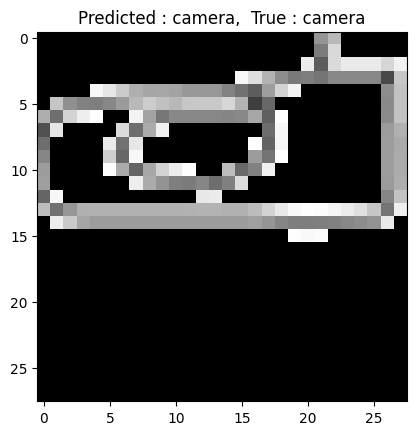

In [95]:
random = np.random.randint(test_img.shape[0])
img,correct = torch.tensor(test_img[random]).reshape(1,1,28,28).float().to(divice), test_lbl[random]
pred = model(img).to(divice)

true = classes[correct]
predicted = classes[pred.argmax(1).item()] 
plt.title(f'Predicted : {predicted},  True : {true}')
plt.imshow(img.reshape(28,28), cmap = 'gray')